## 1) Objective

This notebook extends the raw-data overview with deeper data understanding:
- table-level summary and schema checks
- missing-value analysis
- basic distribution plots for order behavior
- quick quality checks before preparation/EDA

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

DATA_PATH = '../../data/raw/'

orders = pd.read_csv(f'{DATA_PATH}orders.csv')
products = pd.read_csv(f'{DATA_PATH}products.csv')
prior = pd.read_csv(f'{DATA_PATH}order_products__prior.csv')
departments = pd.read_csv(f'{DATA_PATH}departments.csv')
aisles = pd.read_csv(f'{DATA_PATH}aisles.csv')

tables = {
    "orders": orders,
    "products": products,
    "prior": prior,
    "departments": departments,
    "aisles": aisles
}

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [19]:
# Create order_date by anchoring each user's latest order to a snapshot date
# Reference: The Instacart dataset snapshot is typically set to 2015-07-01
snapshot_date = pd.Timestamp('2015-07-01')

# Sort orders chronologically within each user
orders_sorted = orders.sort_values(['user_id', 'order_number']).reset_index(drop=True)

# First order (order_number=1) has no prior gap
orders_sorted['days_since_prior_order'] = orders_sorted['days_since_prior_order'].fillna(0)

# Elapsed days from each customer's first order
orders_sorted['cumulative_days'] = orders_sorted.groupby('user_id')['days_since_prior_order'].cumsum()

# Back-calculate dates so the latest order aligns with the snapshot date
max_cumulative_days = orders_sorted.groupby('user_id')['cumulative_days'].transform('max')
orders_sorted['order_date'] = snapshot_date - pd.to_timedelta(
    max_cumulative_days - orders_sorted['cumulative_days'], unit='D'
)

# Restore original row order
orders_with_dates = orders.copy()
orders_with_dates = orders_with_dates.merge(
    orders_sorted[['order_id', 'cumulative_days', 'order_date']],
    on='order_id',
    how='left'
)

print(f"✓ Created cumulative_days and order_date columns")
print(f"✓ Snapshot date: {snapshot_date}")
print(f"✓ Date range: {orders_with_dates['order_date'].min()} to {orders_with_dates['order_date'].max()}")
print(f"\nSample rows with dates:")
display(orders_with_dates[['order_id', 'user_id', 'order_number', 'days_since_prior_order', 'cumulative_days', 'order_date']].head(10))

✓ Created cumulative_days and order_date columns
✓ Snapshot date: 2015-07-01 00:00:00
✓ Date range: 2014-07-01 00:00:00 to 2015-07-01 00:00:00

Sample rows with dates:


,order_id,user_id,order_number,days_since_prior_order,cumulative_days,order_date
0,2539329,1,1,NaN,0.0000,2014-12-23
1,2398795,1,2,15.0000,15.0000,2015-01-07
2,473747,1,3,21.0000,36.0000,2015-01-28
3,2254736,1,4,29.0000,65.0000,2015-02-26
4,431534,1,5,28.0000,93.0000,2015-03-26
5,3367565,1,6,19.0000,112.0000,2015-04-14
6,550135,1,7,20.0000,132.0000,2015-05-04
7,3108588,1,8,14.0000,146.0000,2015-05-18
8,2295261,1,9,0.0000,146.0000,2015-05-18
9,2550362,1,10,30.0000,176.0000,2015-06-17


In [20]:
# 1. กำหนดโฟลเดอร์ปลายทางตรงๆ
output_path = '../../data/processed/features/orders_with_dates.csv'

# 2. เซฟไฟล์
orders_with_dates.to_csv(output_path, index=False)

# 3. ปริ้นท์เช็คผลนิดหน่อย
print(f"เซฟเรียบร้อย! ที่: {output_path} | จำนวน: {len(orders_with_dates):,} แถว")

เซฟเรียบร้อย! ที่: ../../data/processed/features/orders_with_dates.csv | จำนวน: 3,421,083 แถว


In [21]:
# Optional sample export for git-tracked artifact
orders_sample_path = output_dir / 'orders_with_dates_sample.csv'
orders_with_dates.sample(n=min(1000, len(orders_with_dates)), random_state=42).to_csv(
    orders_sample_path,
    index=False,
)

print(f"Saved sample artifact to: {orders_sample_path}")

Saved sample artifact to: /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/processed/features/orders_with_dates_sample.csv


## 2) Table Size and Structure Summary

In [22]:
overview = pd.DataFrame({
    'table': list(tables.keys()),
    'rows': [df.shape[0] for df in tables.values()],
    'cols': [df.shape[1] for df in tables.values()],
    'memory_mb': [round(df.memory_usage(deep=True).sum() / 1024**2, 2) for df in tables.values()],
    'duplicate_rows': [int(df.duplicated().sum()) for df in tables.values()],
    'total_missing_cells': [int(df.isna().sum().sum()) for df in tables.values()],
}).sort_values('rows', ascending=False)

overview

,table,rows,cols,memory_mb,duplicate_rows,total_missing_cells
2,prior,32434489,4,989.8200,0,0
0,orders,3421083,7,332.7100,0,206209
1,products,49688,4,4.9300,0,0


## 3) Schema Snapshot
Inspect head rows and dtypes for each table.

In [23]:
for name, df in tables.items():
    print(f'\n=== {name} ===')
    display(df.head(3))
    display(df.dtypes.rename('dtype').to_frame())


=== orders ===


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0000
2,473747,1,prior,3,3,12,21.0000


,dtype
order_id,int64
user_id,int64
eval_set,str
order_number,int64
order_dow,int64
order_hour_of_day,int64
days_since_prior_order,float64



=== products ===


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


,dtype
product_id,int64
product_name,str
aisle_id,int64
department_id,int64



=== prior ===


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


,dtype
order_id,int64
product_id,int64
add_to_cart_order,int64
reordered,int64


In [24]:
table_missing = pd.DataFrame({
    'table': list(tables.keys()),
    'missing_cells': [int(df.isna().sum().sum()) for df in tables.values()],
    'missing_pct_all_cells': [round((df.isna().sum().sum() / df.size) * 100, 4) for df in tables.values()]
}).sort_values('missing_cells', ascending=False)

table_missing

,table,missing_cells,missing_pct_all_cells
0,orders,206209,0.8611
1,products,0,0.0000
2,prior,0,0.0000


### Column-level Missing Details
Show columns with missing values ranked by percentage and count.

In [25]:
missing_by_column = (
    pd.concat(
        [
            pd.DataFrame({
                'table': name,
                'column': df.columns,
                'missing_count': df.isna().sum().values,
                'missing_pct': (df.isna().mean() * 100).values,
            })
            for name, df in tables.items()
        ],
        ignore_index=True,
    )
    .query('missing_count > 0')
    .sort_values(['missing_pct', 'missing_count'], ascending=False)
)

missing_by_column.head(20)

,table,column,missing_count,missing_pct
6,orders,days_since_prior_order,206209,6.0276


## 5) Basic Plots
Quick visual checks on order behavior and reorder tendency.

/tmp/ipykernel_9786/2889887778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='eval_set', ax=axes[0], palette=['#4C78A8', '#F58518', '#54A24B'])


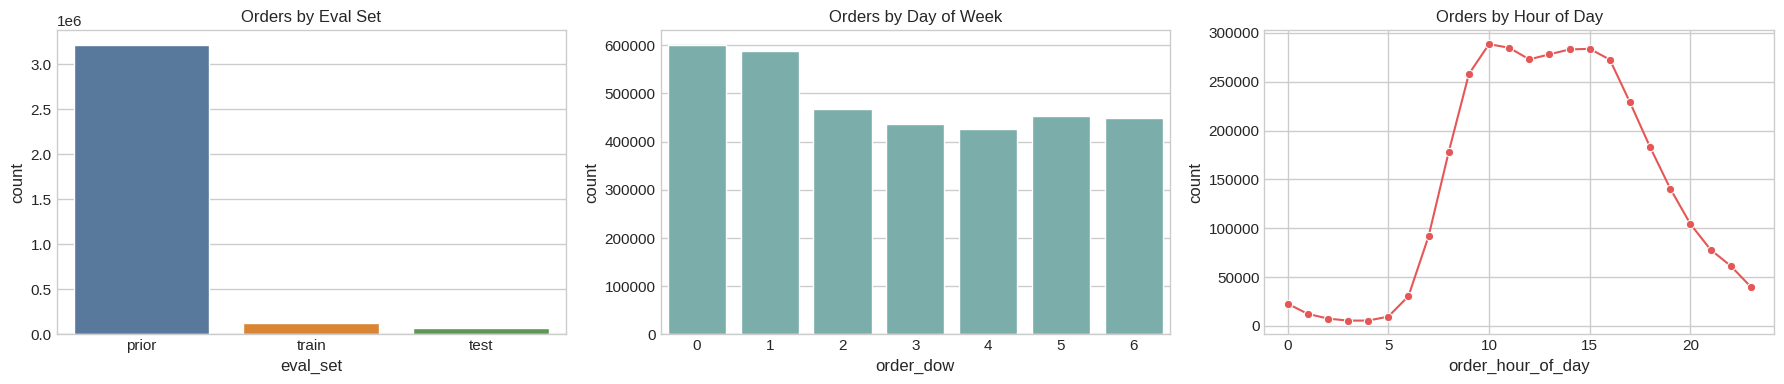

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=orders, x='eval_set', ax=axes[0], palette=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Orders by Eval Set')
axes[0].set_xlabel('eval_set')
axes[0].set_ylabel('count')

sns.countplot(data=orders, x='order_dow', ax=axes[1], color='#72B7B2')
axes[1].set_title('Orders by Day of Week')
axes[1].set_xlabel('order_dow')
axes[1].set_ylabel('count')

hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
sns.lineplot(x=hour_counts.index, y=hour_counts.values, ax=axes[2], color='#E45756', marker='o')
axes[2].set_title('Orders by Hour of Day')
axes[2].set_xlabel('order_hour_of_day')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9786/2626577771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=prior, x='reordered', ax=axes[0], palette=['#F2CF5B', '#2E8B57'])


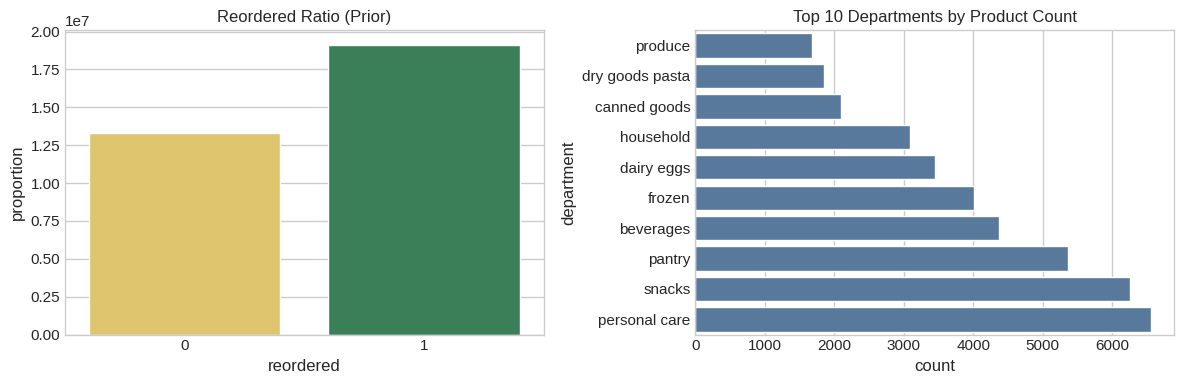

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=prior, x='reordered', ax=axes[0], palette=['#F2CF5B', '#2E8B57'])
axes[0].set_title('Reordered Ratio (Prior)')
axes[0].set_xlabel('reordered')
axes[0].set_ylabel('proportion')

# Top departments by number of product records
product_dept = products.merge(departments, on='department_id', how='left')
top_departments = product_dept['department'].value_counts().head(10).sort_values()
sns.barplot(x=top_departments.values, y=top_departments.index, ax=axes[1], color='#4C78A8')
axes[1].set_title('Top 10 Departments by Product Count')
axes[1].set_xlabel('count')
axes[1].set_ylabel('department')

plt.tight_layout()
plt.show()

## 6) Key Integrity Checks
Validate key uniqueness and relationship consistency across tables.

In [42]:
checks = {
    'orders.order_id_unique': orders['order_id'].is_unique,
    'products.product_id_unique': products['product_id'].is_unique,
    'aisles.aisle_id_unique': aisles['aisle_id'].is_unique,
    'departments.department_id_unique': departments['department_id'].is_unique,
    'prior.order_id_in_orders_pct': round(prior['order_id'].isin(orders['order_id']).mean() * 100, 2),
    'prior.product_id_in_products_pct': round(prior['product_id'].isin(products['product_id']).mean() * 100, 2), 
}

pd.Series(checks, name='result')

orders.order_id_unique                 True
products.product_id_unique             True
aisles.aisle_id_unique                 True
departments.department_id_unique       True
prior.order_id_in_orders_pct       100.0000
prior.product_id_in_products_pct   100.0000
Name: result, dtype: object